In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

In [23]:
X, y = make_moons(100, noise=0.25,random_state=2)

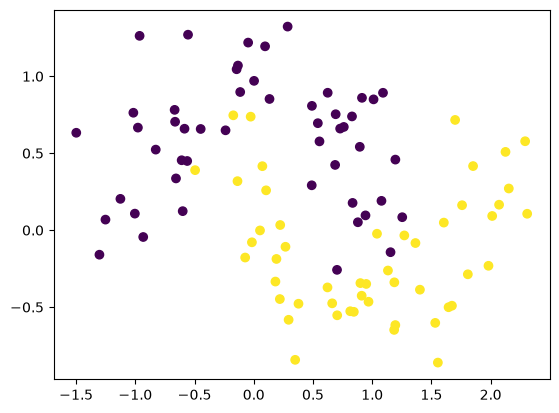

In [24]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

In [4]:
model1 = Sequential()

model1.add(Dense(128,input_dim=2, activation="relu"))
model1.add(Dense(128, activation="relu"))
model1.add(Dense(1,activation='sigmoid'))

model1.summary()

C:\Users\Shekhar Kumar\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
adam = Adam(learning_rate=0.01)
model1.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])
history1 = model1.fit(X, y, epochs=900, validation_split = 0.2,verbose=1)

Epoch 1/900
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 246ms/step - accuracy: 1.0000 - loss: 2.4600e-04 - val_accuracy: 0.9500 - val_loss: 0.4715
Epoch 2/900
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.9000 - val_loss: 0.9518
Epoch 3/900
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 1.0000 - loss: 0.0084 - val_accuracy: 0.9500 - val_loss: 0.5335
Epoch 4/900
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 1.0000 - loss: 0.0037 - val_accuracy: 0.9500 - val_loss: 0.3452
Epoch 5/900
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9875 - loss: 0.0577 - val_accuracy: 0.9500 - val_loss: 0.5943
Epoch 6/900
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 1.0000 - loss: 1.1818e-04 - val_accuracy: 0.9500 - val_loss: 0.7711
Epoch 7/900
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9875 - loss: 0.0217 - val_accuracy: 0.9500 - val_loss: 0.7892
Epoch 8/900
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.9500 - 

In [26]:
class KerasClassifier:
    def __init__(self, model):
        self.model = model

    def predict(self, X):
        predictions = self.model.predict(X, verbose=0)
        return (predictions >= 0.5).astype(int).ravel()

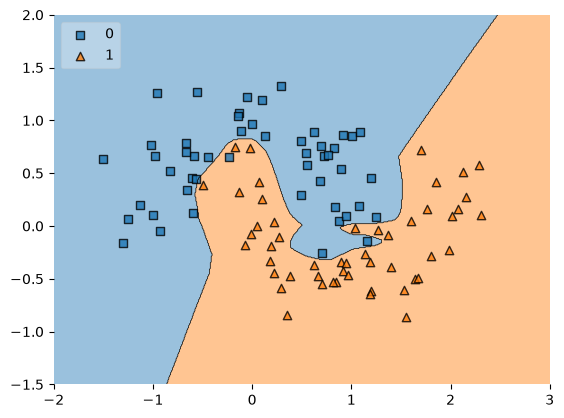

In [9]:
from mlxtend.plotting import plot_decision_regions

clf = KerasClassifier(model1)

plot_decision_regions(
    X,
    y.astype(int),
    clf=clf,
    legend=2
)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

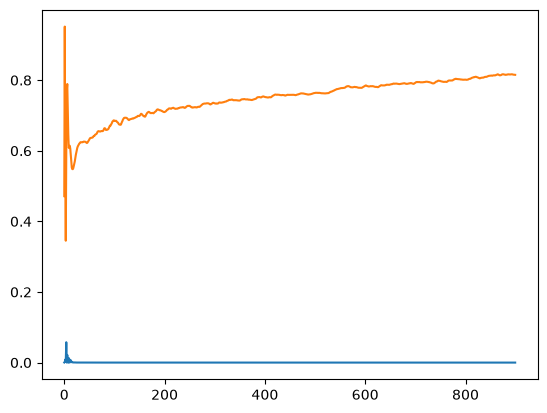

In [10]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

In [31]:
model2 = Sequential()

model2.add(Dense(128,input_dim=2, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l2(0.1)))
model2.add(Dense(128, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l2(0.1)))
model2.add(Dense(1,activation='sigmoid'))

model2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                      │ (None, 128)                 │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
adam = Adam(learning_rate=0.01)
model2.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history2 = model2.fit(X, y, epochs=500, validation_split = 0.2,verbose=1)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 553ms/step - accuracy: 0.6875 - loss: 11.9298 - val_accuracy: 0.9000 - val_loss: 7.5253
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.7625 - loss: 6.3850 - val_accuracy: 0.9000 - val_loss: 3.7785
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.8125 - loss: 3.1735 - val_accuracy: 0.9000 - val_loss: 1.8542
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.8125 - loss: 1.6169 - val_accuracy: 0.8500 - val_loss: 1.1112
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.7375 - loss: 1.0653 - val_accuracy: 0.8500 - val_loss: 0.9684
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.7500 - loss: 0.9986 - val_accuracy: 0.9000 - val_loss: 1.0128
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8000 - loss: 1.0623 - val_accuracy: 0.8500 - val_loss: 1.0601
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.7500 - loss: 1.0873 - val_accuracy: 0.9000 - val

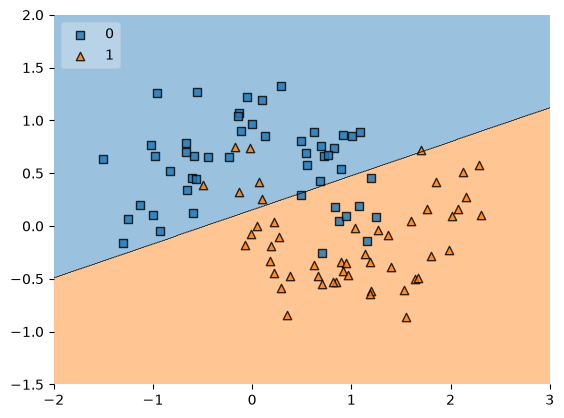

In [33]:
clf = KerasClassifier(model2)

plot_decision_regions(X, y.astype('int'), clf=clf, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

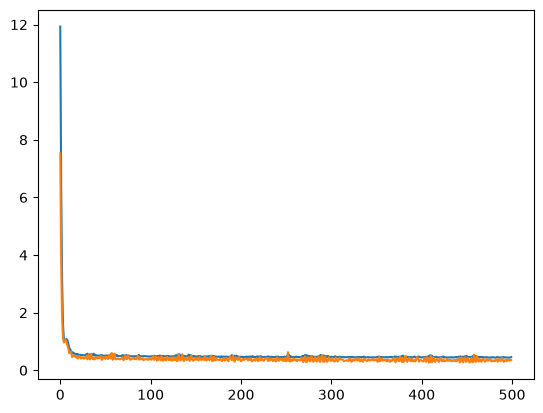

In [34]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

In [35]:
model1_weight_layer1 = model1.get_weights()[0].reshape(256)
model2_weight_layer1 = model2.get_weights()[0].reshape(256)

<Axes: >

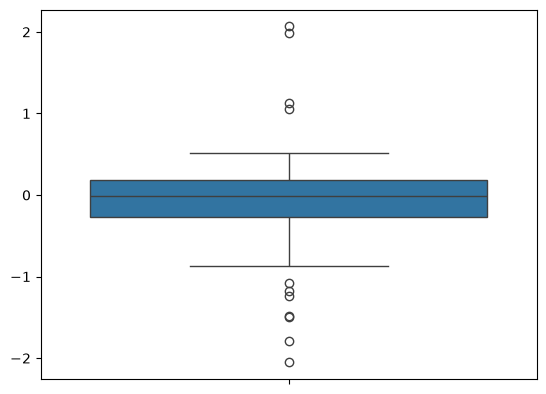

In [36]:
sns.boxplot(model1_weight_layer1)

<Axes: >

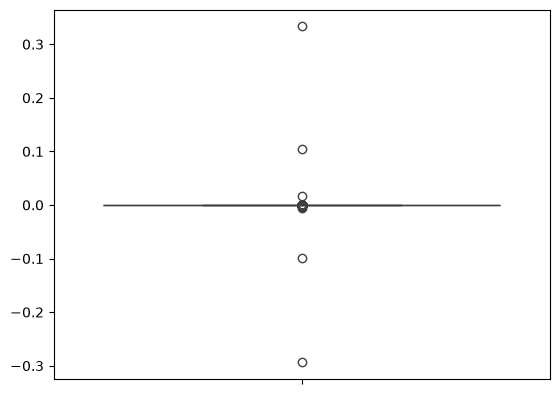

In [37]:
sns.boxplot(model2_weight_layer1)

In [42]:
model1_weight_layer1.max()

np.float32(2.0683286)

In [43]:
model2_weight_layer1.max()

np.float32(0.33338973)

C:\Users\Shekhar Kumar\AppData\Local\Temp\ipykernel_16068\273539155.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model1_weight_layer1,color='g')
C:\Users\Shekhar Kumar\AppData\Local\Temp\ipykernel_16068\273539155.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model2_weight_layer1)


<Axes: ylabel='Density'>

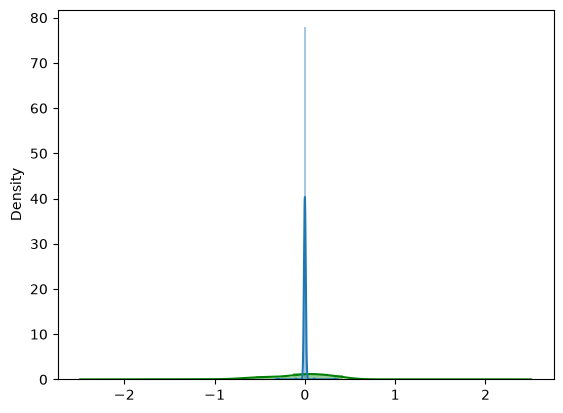

In [41]:
sns.distplot(model1_weight_layer1,color='g')
sns.distplot(model2_weight_layer1)

In [21]:
model1.get_weights()[0].reshape(256)

array([-2.55177677e-01,  3.49071771e-01,  2.47293502e-01, -2.13822901e-01,
       -8.44890997e-03, -4.69575405e-01,  5.11140645e-01, -2.23150969e-01,
       -1.93672001e-01, -2.48010516e-01, -5.68043172e-01, -4.97501582e-01,
       -1.14434771e-01,  3.04573178e-01, -3.93118113e-02,  1.14532746e-01,
       -8.18943918e-01,  3.48774701e-01, -2.15850726e-01,  3.08143437e-01,
       -2.09812596e-01, -1.27821579e-03, -5.30321896e-01,  9.26746354e-02,
       -5.64775407e-01, -3.71175945e-01, -6.87799871e-01, -4.86236781e-01,
       -4.04440850e-01, -2.84448117e-01, -7.19775975e-01, -2.67845184e-01,
        4.00547028e-01, -4.79692332e-02,  3.74780178e-01, -4.78379905e-01,
        1.37001023e-01, -4.97873932e-01,  1.03277847e-01,  3.08194071e-01,
        3.51210624e-01, -2.21451849e-01, -1.10213451e-01, -3.72914933e-02,
       -2.24665999e-02, -2.07451805e-01,  3.68080854e-01, -6.28417969e-01,
       -4.92741197e-01, -5.24337947e-01, -2.11655982e-02,  2.54807949e-01,
       -2.63708442e-01,  